# Лабораторная работа: Shapelet Transform

Вам предстоит с нуля реализовать алгоритм Shapelet Transform для извлечения интерпретируемых признаков из временных рядов.

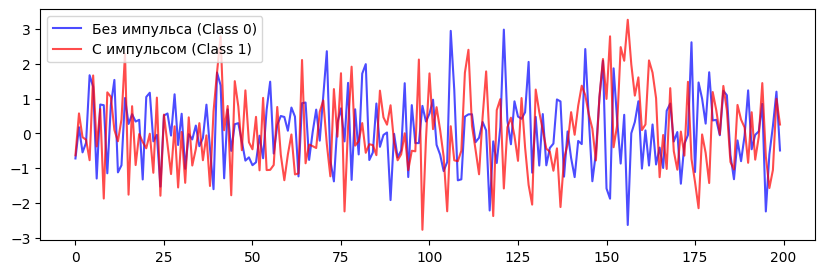

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict, Any

def generate_synthetic_ts_data(n_samples: int = 50, ts_length: int = 200, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    np.random.seed(random_state)
    X_class0 = np.random.normal(0, 1, (n_samples // 2, ts_length))
    y_class0 = np.zeros(n_samples // 2, dtype=int)
    X_class1 = np.random.normal(0, 1, (n_samples // 2, ts_length))
    y_class1 = np.ones(n_samples // 2, dtype=int)
    for i in range(n_samples // 2):
        impulse_len = np.random.randint(15, 30)
        start_idx = np.random.randint(10, ts_length - impulse_len - 10)
        x_impulse = np.linspace(-3, 3, impulse_len)
        X_class1[i, start_idx:start_idx + impulse_len] += np.exp(-0.5 * x_impulse**2) * 2
    X = np.vstack([X_class0, X_class1])
    y = np.hstack([y_class0, y_class1])
    indices = np.random.permutation(n_samples)
    return X[indices], y[indices]


X, y = generate_synthetic_ts_data(n_samples=50, ts_length=200, random_state=42)
plt.figure(figsize=(10, 3))
plt.plot(X[y == 0][0], label='Без импульса (Class 0)', color='blue', alpha=0.7)
plt.plot(X[y == 1][0], label='С импульсом (Class 1)', color='red', alpha=0.7)
plt.legend()
plt.show()

## Задание 1. Генерация кандидатов-шейплетов

**Что нужно сделать:**
Напишите функцию `generate_candidates`, которая находит все **уникальные** подпоследовательности (от `min_len` до `max_len`) из списка временных рядов.

**TODO:** Соберите кандидаты в список и верните.

In [ ]:
def generate_candidates(ts_list: np.ndarray, min_len: int = 3, max_len: int = 20) -> List[np.ndarray]:
    # TODO: Ваш код генерации кандидатов здесь
    candidates = []
    for ts in ts_list:
        ts_len = len(ts)
        for length in range(min_len, max_len + 1):
            for start in range(ts_len - length + 1):
                candidates.append(ts[start:start + length])
    return candidates

## Задание 2. Вычисление расстояний

**Что нужно сделать:**
Разработайте функционал для поиска минимального Евклидова расстояния от шейплета до временного ряда.
Обе последовательности (сам шейплет и скользящее «окно» ряда) при сравнении должны пройти `Z-score` нормализацию.

**TODO:** Написать функции `z_normalize` и `calculate_shapelet_distance`.

In [ ]:
def z_normalize(ts: np.ndarray) -> np.ndarray:
    # TODO: Z-score нормализация (обработать деление на ноль: вернем массив нулей, если std = 0)
    std = np.std(ts)
    if std == 0:
        return np.zeros_like(ts, dtype=float)
    return (ts - np.mean(ts)) / std


def calculate_shapelet_distance(shapelet: np.ndarray, time_series: np.ndarray) -> float:
    # TODO: Найти кратчайшее Евклидово расстояние между нормализованными сэмплами
    shapelet_len = len(shapelet)
    norm_shapelet = z_normalize(shapelet)

    windows = np.lib.stride_tricks.sliding_window_view(time_series, shapelet_len)

    means = windows.mean(axis=1, keepdims=True)
    stds  = windows.std(axis=1, keepdims=True)
    stds[stds == 0] = 1.0
    norm_windows = (windows - means) / stds

    dists = np.sqrt(((norm_windows - norm_shapelet) ** 2).sum(axis=1))
    return float(dists.min())

In [17]:
def _entropy(y: np.ndarray) -> float:
    if len(y) == 0: return 0.0
    p = np.sum(y) / len(y)
    if p == 0 or p == 1.0: return 0.0
    return -p * np.log2(p) - (1.0 - p) * np.log2(1.0 - p)

def calculate_information_gain(distances: np.ndarray, labels: np.ndarray) -> Tuple[float, float]:
    if len(distances) == 0 or len(np.unique(labels)) < 2: return 0.0, 0.0
    sorted_indices = np.argsort(distances)
    sorted_distances = distances[sorted_indices]
    sorted_labels = labels[sorted_indices]
    best_ig, best_split, initial_entropy, n = 0.0, sorted_distances[0], _entropy(labels), len(labels)
    for i in range(1, n):
        ig = initial_entropy - ((len(sorted_labels[:i])/n) * _entropy(sorted_labels[:i]) + ((n-i)/n) * _entropy(sorted_labels[i:]))
        if ig > best_ig: best_ig, best_split = ig, (sorted_distances[i-1] + sorted_distances[i]) / 2.0
    return best_ig, best_split

## Задание 3. Shapelet Transform и алгоритм классификации

**Что нужно сделать:**
Объедините все функции выше! Найдите `top_k` лучших шейплетов (по максимуму `IG`) и трансформируйте исходный датасет временных рядов `X` в матрицу признаков размерности `(n_samples, top_k)`.
Затем натренируйте Random Forest на полученных табличных данных.

**TODO:** Реализовать `shapelet_transform` и предсказать метки.

In [ ]:
def shapelet_transform(
    X: np.ndarray,
    y: np.ndarray,
    top_k: int = 5,
    min_len: int = 10,
    max_len: int = 30,
    max_candidates: int = 500,
    random_state: int = 42
) -> Tuple[np.ndarray, List[Dict[str, Any]]]:
    # TODO:
    # 1. Извлечь кандидатов `generate_candidates` 
    # 2. Для каждого кандидата посчитать расстояния `calculate_shapelet_distance` ко всем временным рядам
    # 3. Высчитать `IG` для каждого `calculate_information_gain` (имеет смысл использовать `.sample()` для скорости)
    # 4. Отсортировать шейплеты по убыванию IG, взять топ K.
    # 5. Сформировать новую матрицу признаков из Distances лучших шейплетов
    rng = np.random.default_rng(random_state)
    n_samples = len(X)

    all_candidates = generate_candidates(X, min_len=min_len, max_len=max_len)
    if len(all_candidates) > max_candidates:
        idx = rng.choice(len(all_candidates), size=max_candidates, replace=False)
        candidates = [all_candidates[i] for i in idx]
    else:
        candidates = all_candidates
    print(f"Кандидатов всего: {len(all_candidates)}, используем: {len(candidates)}")

    shapelet_scores = []
    for idx, candidate in enumerate(candidates):
        shapelet_len = len(candidate)
        norm_shapelet = z_normalize(candidate)

        windows_all = np.lib.stride_tricks.sliding_window_view(X, (1, shapelet_len)).reshape(n_samples, -1, shapelet_len)
        means = windows_all.mean(axis=2, keepdims=True)
        stds  = windows_all.std(axis=2, keepdims=True)
        stds[stds == 0] = 1.0
        norm_windows_all = (windows_all - means) / stds

        dists = np.sqrt(((norm_windows_all - norm_shapelet) ** 2).sum(axis=2))
        distances = dists.min(axis=1)

        ig, split = calculate_information_gain(distances, y)
        shapelet_scores.append({
            'shapelet': candidate,
            'ig': ig,
            'split': split,
            'distances': distances
        })
        if (idx + 1) % 100 == 0:
            print(f"  Обработано {idx + 1}/{len(candidates)} кандидатов...")

    shapelet_scores.sort(key=lambda s: s['ig'], reverse=True)
    top_shapelets = shapelet_scores[:top_k]

    features = np.column_stack([s['distances'] for s in top_shapelets])

    return features, top_shapelets

Кандидатов всего: 190050, используем: 500
  Обработано 100/500 кандидатов...
  Обработано 200/500 кандидатов...
  Обработано 300/500 кандидатов...
  Обработано 400/500 кандидатов...
  Обработано 500/500 кандидатов...
Форма новых признаков: (50, 5)
Accuracy: 0.8

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.75      0.80         8
           1       0.75      0.86      0.80         7

    accuracy                           0.80        15
   macro avg       0.80      0.80      0.80        15
weighted avg       0.81      0.80      0.80        15



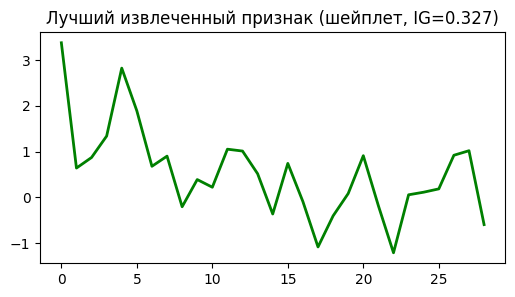

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

features, top_shapelets = shapelet_transform(X, y, top_k=5)
print(f"Форма новых признаков: {features.shape}")

X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.3, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

best_shapelet = top_shapelets[0]['shapelet']
plt.figure(figsize=(6, 3))
plt.plot(best_shapelet, color='green', linewidth=2)
plt.title(f"Лучший извлеченный признак (шейплет, IG={top_shapelets[0]['ig']:.3f})")
plt.show()